# Building an electorate to order

The other notebooks draw voters at random and ask who wins. This one runs the question backwards: fix the winners first, then solve for an electorate that elects them.

The unknown is one count per ranking - `x[sigma]` voters holding ranking `sigma`.

    score_R(w) >= score_R(j) + 1    for every other candidate j

Not every target is reachable, though. Of the `M!` rankings on paper only some are realizable by a point in the plane.

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [2]:
from voting import (
    Candidate,
    Voter,
    Election,
    PluralityRule,
    BordaRule,
    VetoRule,
    LpModel,
    find_farthest_pair,
    find_farthest_triple,
    rule_for_key,
)

from voting.plotting import (
    plot_election,
    plot_result,
    random_2d_point,
)


The check below is the end-to-end one. The LP claims an electorate exists *in
the plane*, so what settles it is running the generated positions through the
ordinary `Election` pipeline - which also puts the LP's linear score
expressions against the numpy ones in `rules.py`, two independent
implementations of the same tally.

`model.check()` would read the ranking counts back instead, without ever
looking at a point. Useful for working out *where* a failure came from, but it
verifies the LP against itself, so it is left out.

In [3]:
def verify_lp_winners(model, voter_positions):
    """Check that the generated voters really do elect the targets.

    The LP claims an electorate exists *in the plane*, so what settles it is
    running the generated positions through the ordinary `Election` pipeline.
    That also puts the LP's linear score expressions against the numpy ones in
    `rules.py` - two independent implementations of the same tally.

    `model.check()` is deliberately not used here. It reads the ranking counts
    back without ever looking at a point, so it verifies the LP against itself;
    handy for localising a failure, but it settles nothing this does not.
    """
    # A swap model's fixed electorate counts towards the tally but is not part
    # of generate_voter_positions(), so it has to be put back.
    base = [getattr(v, "position", v) for v in (model.voters or [])]
    election = Election(
        candidates=model.candidates,
        voters=[Voter(position=p) for p in [*base, *voter_positions]],
    )
    result = election.compare([rule_for_key(key) for key in model.winners])

    added = len(voter_positions)
    size_ok = (
        added == model.n_voters
        if model.n_voters is not None
        else added <= model.max_added
    )
    assert size_ok, f"LP returned {added} voters, breaking the size constraint"

    print(f"voters: {election.n_voters}")
    print()
    print(f"{'rule':<12} {'target':>7} {'actual':>7} {'margin':>8}")
    for key, target in model.winners.items():
        tally = result.tally(key)
        print(f"{key:<12} {target:>7} {tally.winner_index:>7} {tally.margin:>8g}")
        # A tie has no winner - winner_index falls back to the lowest index.
        assert not tally.is_tie(), f"{key} is tied, so it has no winner"
        assert tally.winner_index == target, f"{key}: wanted {target}"


## Targets chosen by hand

Candidates placed deliberately, and rules asked to disagree across the board.

In [4]:
N_VOTERS = 100
N_CANDIDATES = 3

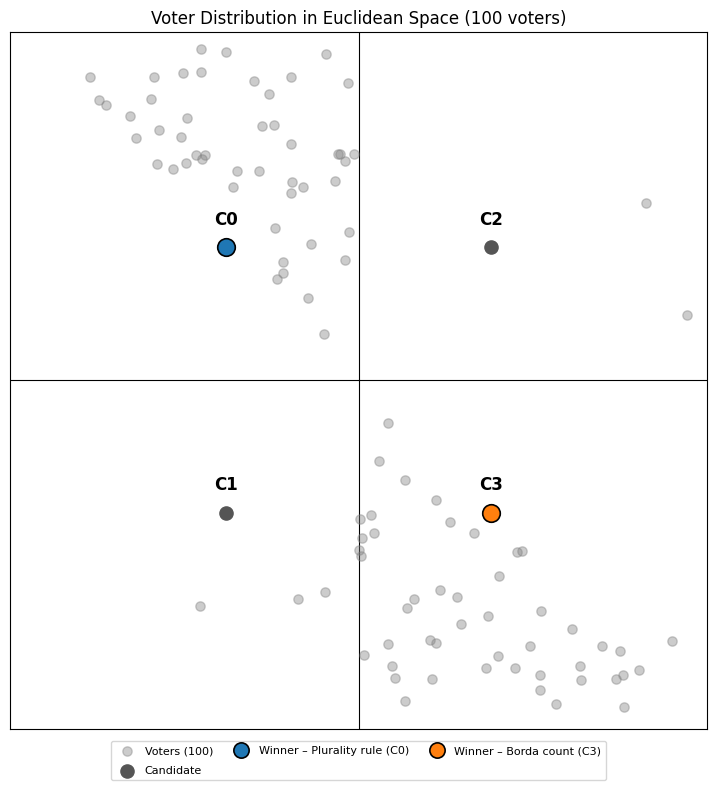

<Axes: title={'center': 'Voter Distribution in Euclidean Space (100 voters)'}>

In [5]:
positions = [(-4, 4), (-4, -4), (4, 4), (4, -4)]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

winners = {
    PluralityRule(): 0,
    BordaRule(): 3,
}

model = LpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

plot_election(candidates, model.generate_voter_positions(), winners, regions=True)

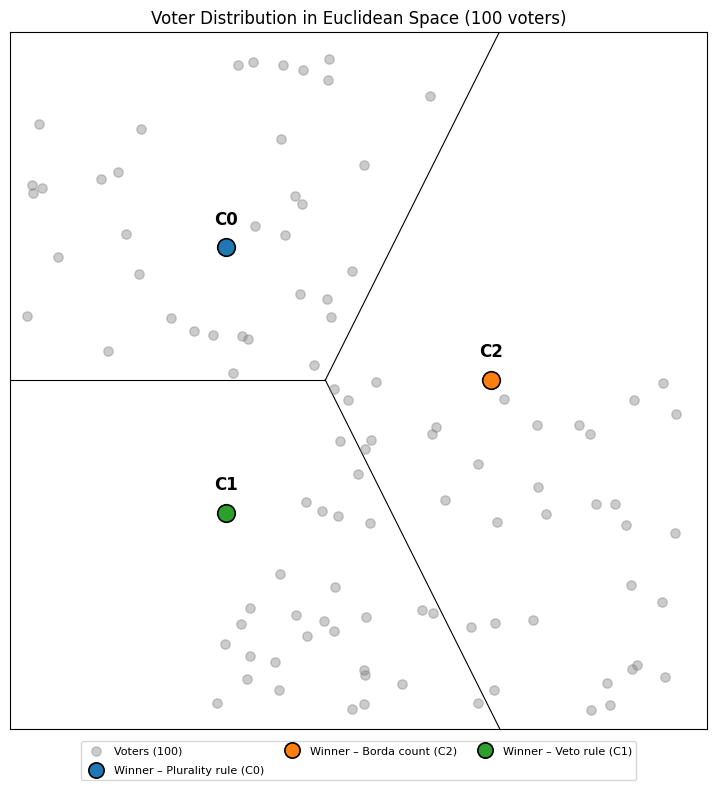

<Axes: title={'center': 'Voter Distribution in Euclidean Space (100 voters)'}>

In [6]:
positions = [
    (-4, 4),
    (-4, -4),
    (4, 0),
]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

winners = {
    PluralityRule(): 0,
    BordaRule(): 2,
    VetoRule(): 1
}

model = LpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

plot_election(candidates, model.generate_voter_positions(), winners, regions=True)

## Random candidates, random targets

Drawing positions and winners independently usually asks for something the plane
cannot deliver, so the loop below keeps drawing until a combination turns out
achievable. The targets are drawn without replacement, so the rules are
always asked for three different winners.

Veto is the fussiest of the three - veto ties almost always.

achievable after 2 attempt(s): {'plurality': 3, 'borda': 2, 'veto': 1}


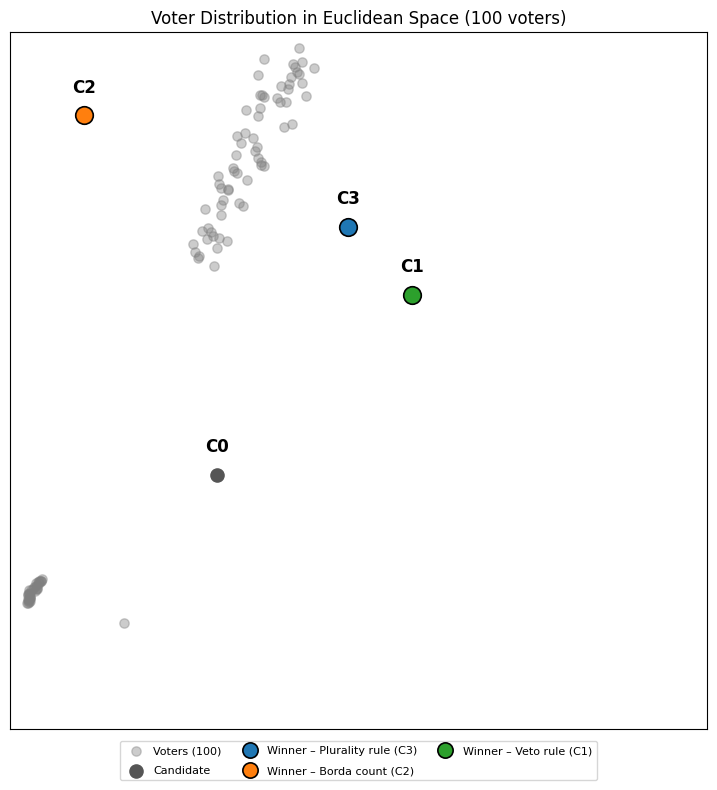

voters: 100

rule          target  actual   margin
plurality          3       3       30
borda              2       2        2
veto               1       1        1


In [7]:
N_VOTERS = 100
N_CANDIDATES = 4

# Not every combination of winners can be realized by points in the plane, so
# draw candidate positions and targets until a combination turns out achievable.
# (Asserting "Optimal" on a single random draw fails often.)
rules = [PluralityRule(), BordaRule(), VetoRule()]

for attempt in range(1, 201):
    candidates = [
        Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
    ]
    # Drawn without replacement
    targets = random.sample(range(N_CANDIDATES), len(rules))
    winners = {rule.key: target for rule, target in zip(rules, targets)}

    model = LpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
    if model.solve() == "Optimal":
        break
else:
    raise RuntimeError("no achievable combination of winners found in 200 attempts")

print(f"achievable after {attempt} attempt(s): {winners}")

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners)

verify_lp_winners(model, voter_positions)

## Reproducing an observed election

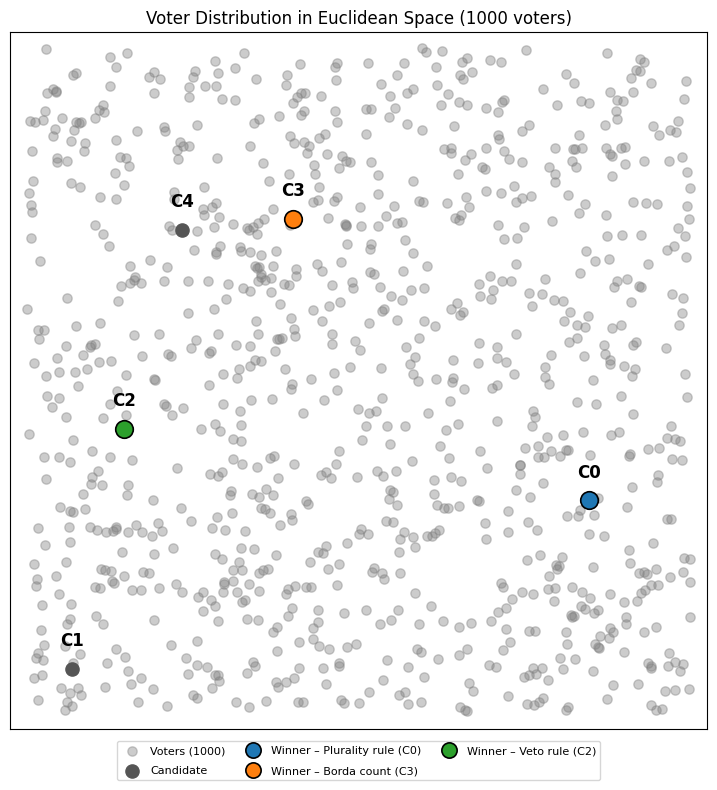

<Axes: title={'center': 'Voter Distribution in Euclidean Space (1000 voters)'}>

In [11]:
N_VOTERS = 1000
N_CANDIDATES = 5


RULES = [PluralityRule(), BordaRule(), VetoRule()]

while True:
    candidates = [
        Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
    ]
    voters = [Voter(position=random_2d_point()) for _ in range(N_VOTERS)]
    election = Election(candidates=candidates, voters=voters)
    election_result = election.compare(RULES)
    if not election_result.has_tie() and election_result.winners_all_distinct():
        break

plot_result(election_result)

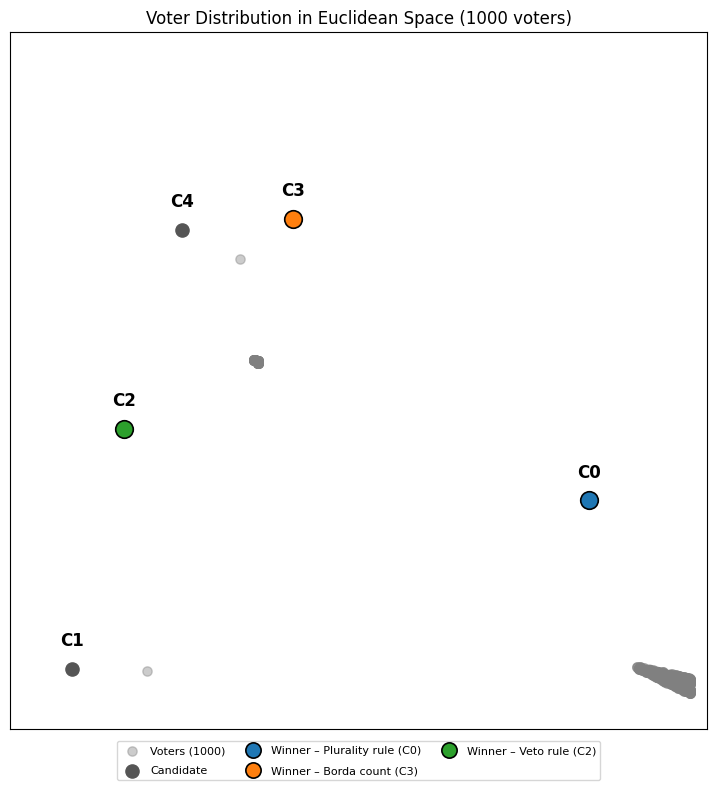

voters: 1000

rule          target  actual   margin
plurality          0       0      598
borda              3       3        3
veto               2       2        1


In [12]:
winners = election_result.winner_indices()
model = LpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the positions once, then plot and verify the same electorate.
voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners)

verify_lp_winners(model, voter_positions)

### Which feasible electorate?

The targets usually leave many electorates to choose from, and `objective` picks
among them. `feasibility` takes whatever the solver reaches first; `minmax`
keeps the fullest region as small as it can, `maxmin` lifts the emptiest one, and
`range` squeezes the gap between the two.

None of them touch the winners - every run below verifies the same targets. What
changes is how the support is spread, which is what the plots show.

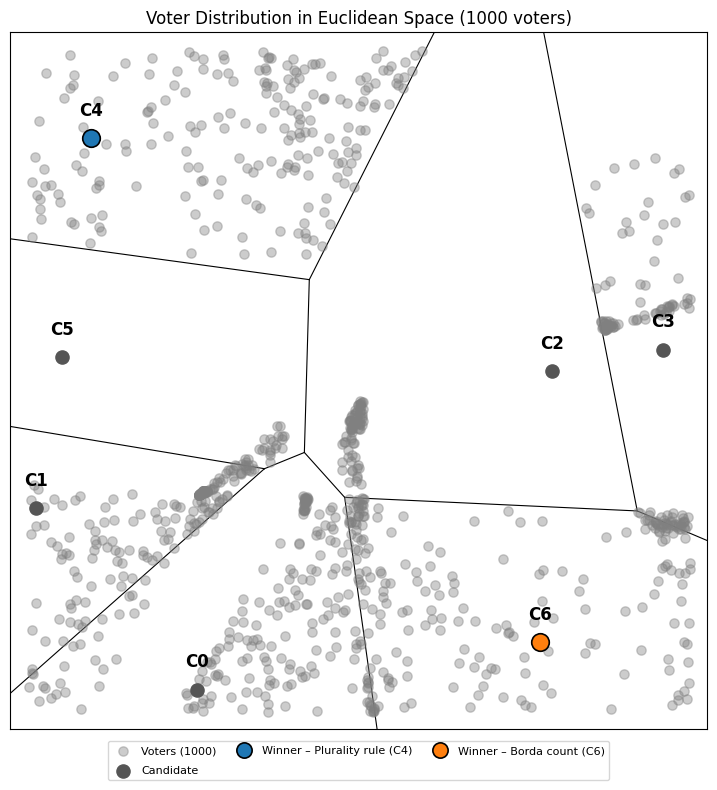

voters: 1000

rule          target  actual   margin
plurality          4       4        1
borda              6       6        1


In [23]:
model = LpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="minmax"
)
model_result = model.solve()
assert model_result == "Optimal"

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners, regions=True)

verify_lp_winners(model, voter_positions)

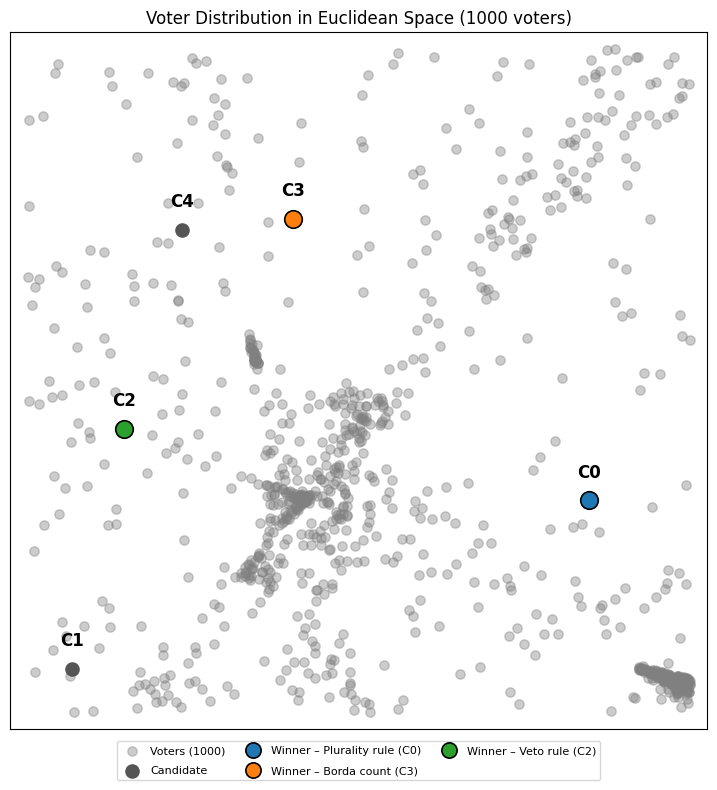

voters: 1000

rule          target  actual   margin
plurality          0       0       13
borda              3       3       37
veto               2       2       72


In [14]:
model = LpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="maxmin"
)
model_result = model.solve()
assert model_result == "Optimal"

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners)

verify_lp_winners(model, voter_positions)

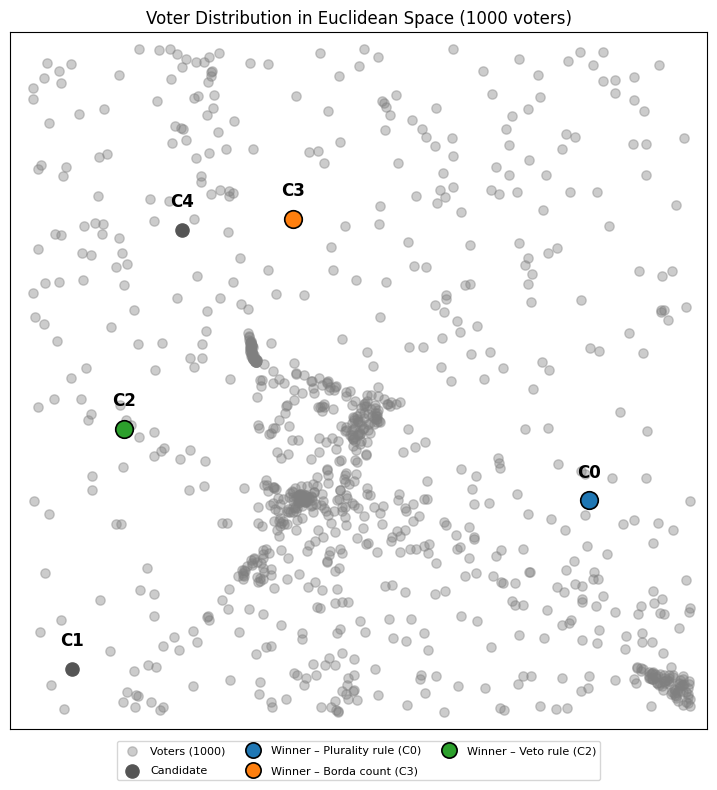

voters: 1000

rule          target  actual   margin
plurality          0       0        1
borda              3       3       14
veto               2       2       60


In [15]:
model = LpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="range"
)
model_result = model.solve()
assert model_result == "Optimal"

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners)

verify_lp_winners(model, voter_positions)

## Targets as far apart as possible

Instead of an arbitrary pair of winners, ask for the two candidates standing
furthest from each other: the widest winner dispersion the configuration admits.
The same four objectives follow, so these plots read directly against the
section above.

In [16]:
N_VOTERS = 1000
N_CANDIDATES = 7

for attempt in range(1, 101):
    candidates = [
        Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
    ]
    idxs = find_farthest_pair([candidate.position for candidate in candidates])

    winners = {
        PluralityRule(): idxs[0],
        BordaRule(): idxs[1],
    }

    model = LpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)

    if model.solve() == "Optimal":
        break
else:
    # Without this the loop falls through holding an unsolved model, and the
    # cells below would go on to "verify" an empty electorate.
    raise RuntimeError("no achievable farthest-pair target found in 100 attempts")

print(f"achievable after {attempt} attempt(s): {winners}")

achievable after 1 attempt(s): {PluralityRule(): 4, BordaRule(): 6}


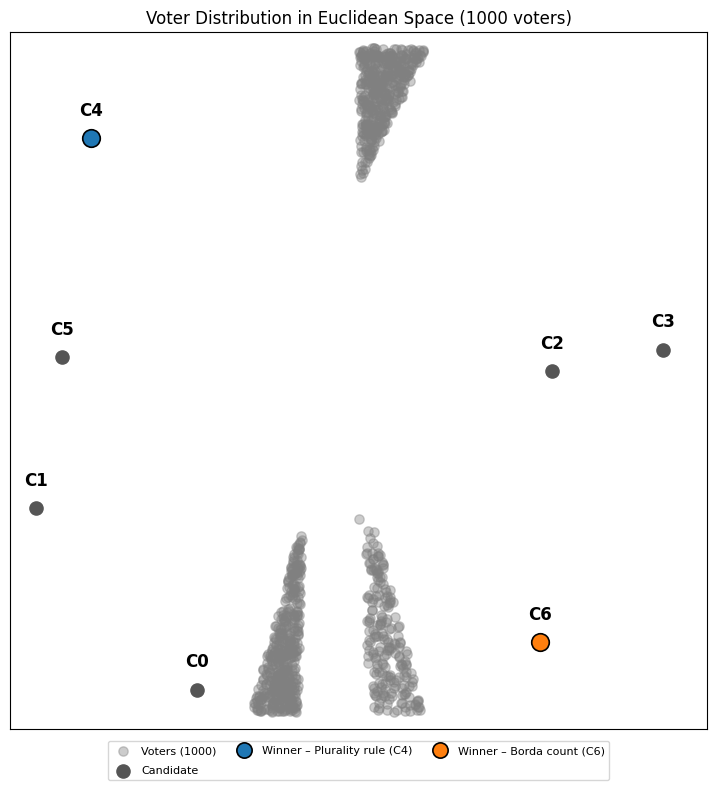

voters: 1000

rule          target  actual   margin
plurality          4       4        1
borda              6       6        4


In [17]:
voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners)

verify_lp_winners(model, voter_positions)

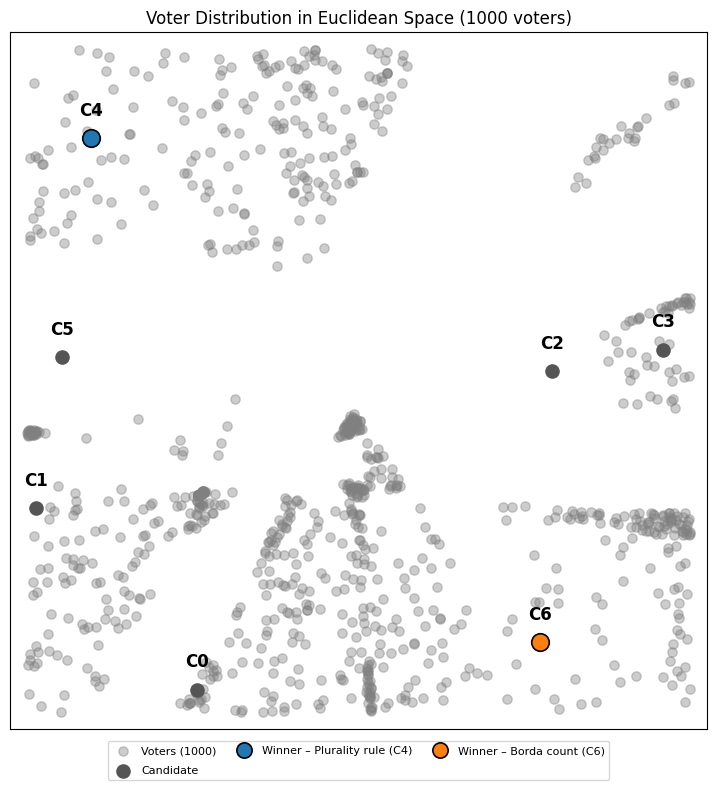

voters: 1000

rule          target  actual   margin
plurality          4       4        1
borda              6       6        1


In [18]:
model = LpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="minmax"
)
model_result = model.solve()
assert model_result == "Optimal"

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners)

verify_lp_winners(model, voter_positions)

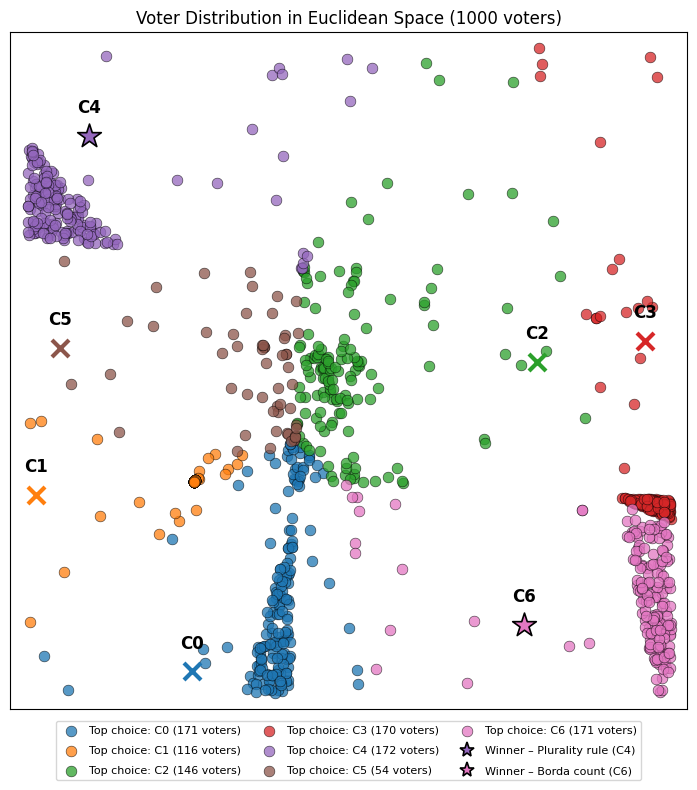

voters: 1000

rule          target  actual   margin
plurality          4       4        1
borda              6       6        1


In [25]:
model = LpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="maxmin"
)
model_result = model.solve()
assert model_result == "Optimal"

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners, color_voters=True)

verify_lp_winners(model, voter_positions)

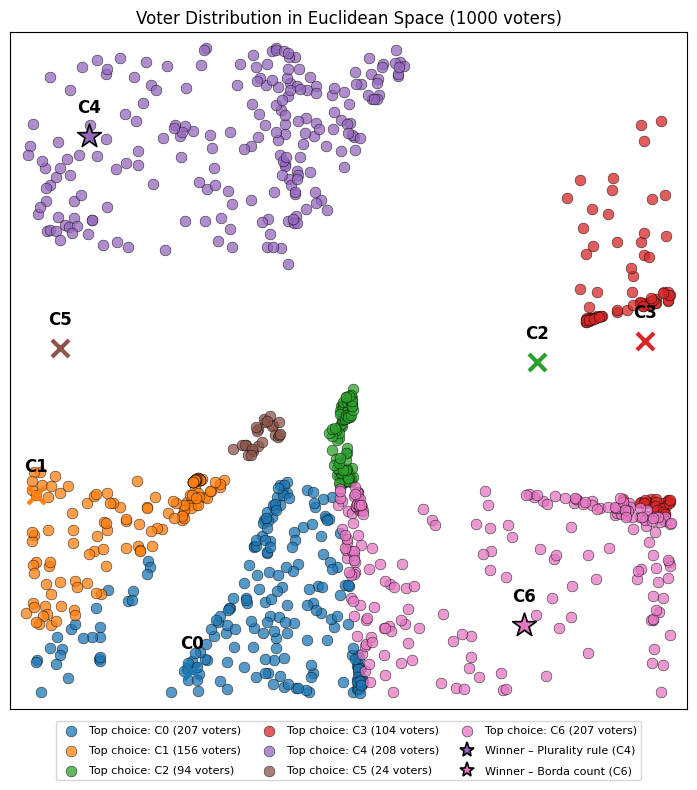

voters: 1000

rule          target  actual   margin
plurality          4       4        1
borda              6       6        1


In [26]:
model = LpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="range"
)
model_result = model.solve()
assert model_result == "Optimal"

voter_positions = model.generate_voter_positions()
plot_election(candidates, voter_positions, winners, color_voters=True)

verify_lp_winners(model, voter_positions)